# Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split



## Load data

In [2]:
# Define paths and file names
root_path = '/content/'
data_path = root_path
tf_filenames_dict = {
    'maize'     : 'Zma_TF_list.txt',
    'rice'      : 'Osj_TF_list.txt',
    'sorghum'   : 'Sbi_TF_list.txt'
}

Load expression data

In [3]:
# Load and format expression data
exp_data = pd.read_csv("/content/zma_osa_sbi_ortho_hai_expr_all.tsv", sep='\t')
exp_data.columns = [col.lower().replace('.','_') for col in exp_data.columns]
exp_data.head()

,gene_id,mean_leaf_section_1,mean_leaf_section_2,mean_leaf_section_3,mean_leaf_section_4,mean_leaf_section_6,mean_leaf_section_7,mean_leaf_section_8,mean_leaf_section_9,mean_leaf_section_10,...,srr6257228_mean,srr6257231_mean,srr8401514_mean,srr9202997_mean,srr9202998_mean,srr9203000_mean,srr9203001_mean,srr9203002_mean,srr9203003_mean,srr9203005_mean
0,ORTHO04M000001,4.546497,6.520382,6.253503,6.826752,6.745223,3.363057,5.000000,4.141401,4.249045,...,2.605618,1.835184,1.601559,2.432007,1.622150,2.686271,1.748511,2.181920,2.756412,2.326934
1,ORTHO04M000002,5.568790,10.509554,11.924204,7.954140,3.438217,0.000000,1.582803,1.537580,1.446497,...,10.177549,3.879458,0.796495,6.654203,1.350818,4.058331,6.377811,3.781891,2.106601,6.723717
2,ORTHO04M000003,5.755689,4.791018,4.871257,5.071257,4.532335,0.161677,3.382036,2.816168,3.359880,...,28.256274,29.906009,3.003803,9.677179,7.787140,10.327200,13.166616,9.940935,9.422623,13.480669
3,ORTHO04M000004,5.931737,7.356886,9.832934,9.923952,6.170659,0.000000,3.388623,2.559281,2.589820,...,5.598559,7.510683,2.290947,3.690457,2.634284,4.460366,4.990626,3.275099,3.170542,5.966543
4,ORTHO04M000005,22.267045,31.086364,33.167045,26.302273,12.117045,2.005682,7.471591,6.215909,5.164773,...,8.677945,10.664965,1.042287,10.677949,1.715857,7.845614,13.432008,10.941222,4.615420,18.174727


Load TF data

In [4]:
# Load TF data from PlantDB
tf_data_dict = {}
all_tf_gene_ids = []
for crop, filename in tf_filenames_dict.items():
    # Load and format data
    temp_df = pd.read_csv(f'{data_path}{filename}', sep='\t')
    temp_df.columns = [col.lower().replace('.','_') for col in temp_df.columns]

    # Add data to dictionary and gene IDs to list
    tf_data_dict[crop] = temp_df
    all_tf_gene_ids += tf_data_dict[crop]['gene_id'].tolist()

# Get a set of unique TF gene IDs
all_tf_gene_ids = set(all_tf_gene_ids)
print(len(all_tf_gene_ids))

6010


Load mapping data

In [5]:
# Load and format ortholog mapping data
map_data = pd.read_csv('/content/orthos_maize_outward.tsv', sep='\t')
map_data.columns = [col.lower().replace('#','') for col in map_data.columns]
map_data['og'] = map_data.og.apply(lambda x: f"ORTHO04M{x[2:].zfill(6)}")

# Get orthologous gene IDs
tf_ortho_ids = (
    map_data.query('orthologous_gene in @all_tf_gene_ids')
    ['og'].unique().tolist()
)
print(len(tf_ortho_ids))

1591


# Graph Autoencoder (GAE)

## Data prep

Only use Arabidopsis map data

In [6]:
# Create a dictionary to map orthologous gene IDs to OG
map_data_ath = map_data.query('orthologous_species == "ath"').copy()
map_data_ath = map_data_ath[['og', 'orthologous_gene']]

Load iGRN network

In [7]:
# Load iGRN network
net_data = pd.read_csv("/content/Data_file1_iGRN_supervised_network_support.txt",
                       sep='\t', header=None, usecols=[0, 1, 2])
net_data.columns = ['Source_AT', 'Target_AT', 'Weight']

# Threshold the network (like stated in paper)
net_data = net_data.query('Weight >= 0.9').copy()

# Map the network to Ortholog Space
# NOTE: using merge for one-to-many mapping (one AT can map to many OGs)
net_data = net_data.merge(
    map_data_ath,
    left_on='Source_AT',
    right_on='orthologous_gene',
    how='inner'
)
net_data = (net_data.rename(columns={'og': 'Source_Ortho'})
            .drop(columns=['orthologous_gene']))
net_data = net_data.merge(
    map_data_ath,
    left_on='Target_AT',
    right_on='orthologous_gene',
    how='inner'
)
net_data = (net_data.rename(columns={'og': 'Target_Ortho'})
            .drop(columns=['orthologous_gene']))

# Build PyTorch Geometric Edge Index
gene_to_index = {gene_id: i for i, gene_id in enumerate(exp_data['gene_id'])}

# Map to indices
net_data['Source_Idx'] = net_data['Source_Ortho'].map(gene_to_index)
net_data['Target_Idx'] = net_data['Target_Ortho'].map(gene_to_index)

# Drop any edges where a node isn't in the expression data
net_data = net_data.dropna(subset=['Source_Idx', 'Target_Idx'])

print(net_data.shape)
print(net_data.head())

(8574, 7)
   Source_AT  Target_AT    Weight    Source_Ortho    Target_Ortho  Source_Idx  \
0  AT4G36920  AT3G61470  0.985894  ORTHO04M000483  ORTHO04M002736       464.0   
1  AT4G36920  AT3G61470  0.985894  ORTHO04M000483  ORTHO04M004007       464.0   
2  AT4G36920  AT3G61470  0.985894  ORTHO04M000483  ORTHO04M009921       464.0   
5  AT4G36920  AT3G61470  0.985894  ORTHO04M008323  ORTHO04M002736      7931.0   
6  AT4G36920  AT3G61470  0.985894  ORTHO04M008323  ORTHO04M004007      7931.0   

   Target_Idx  
0      2619.0  
1      3826.0  
2      9163.0  
5      2619.0  
6      3826.0  


Create edge

In [8]:
import torch

# Convert mapped string IDs to integer row indices
source_indices = net_data['Source_Idx'].astype(int).values
target_indices = net_data['Target_Idx'].astype(int).values

# Create the 2D edge_index tensor
edge_index = torch.tensor(np.array([source_indices, target_indices]),
                          dtype=torch.long)
print(f"Constructed edge_index with shape: {edge_index.shape}")

Constructed edge_index with shape: torch.Size([2, 8574])


Split data into train and test

In [9]:
from sklearn.preprocessing import StandardScaler
# Fill missing values with 0
clean_exp_data = np.log1p(exp_data.fillna(0.0).set_index('gene_id'))

# Identify the experiment columns
experiment_cols = clean_exp_data.columns.tolist()

# Perform an 80:20 split on the column names (experiments)
train_exps, test_exps = train_test_split(experiment_cols, test_size=0.20,
                                         random_state=42)

# Create a masked copy of the expression data for training
train_exp_data_masked = clean_exp_data.copy()
test_exp_data_masked = clean_exp_data.copy()

# Mask the test experiments with 0.0 to prevent data leakage
train_exp_data_masked[test_exps] = 0.0

# Scale the features using ONLY the masked training data
scaler = StandardScaler()
scaled_train_features = scaler.fit_transform(train_exp_data_masked)

# Convert to PyTorch Tensor
X_train_tensor = torch.tensor(scaled_train_features, dtype=torch.float32)

# 2. Put the scaled data back into a DataFrame so we can easily slice it by name
scaled_train_df = pd.DataFrame(
    scaled_train_features,
    index=clean_exp_data.index,
    columns=clean_exp_data.columns
)

# 3. Identify only the Target Genes (exclude the TFs)
target_genes = [g for g in clean_exp_data.index if g not in tf_ortho_ids]

# 4. Slice the DataFrame: Target Genes (rows) and ONLY Training Experiments (columns)
Y_train_df = scaled_train_df.loc[target_genes, train_exps]

# 5. Convert to PyTorch Tensor
Y_train_tensor = torch.tensor(Y_train_df.to_numpy(), dtype=torch.float32)

print(f"Masked Feature Tensor Shape (X_train_tensor): {X_train_tensor.shape}")
print(f"Number of Masked Test Experiments: {len(test_exps)}")

Masked Feature Tensor Shape (X_train_tensor): torch.Size([18449, 698])
Number of Masked Test Experiments: 140


## Training

Build model

In [10]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.9 MB/s eta 0:00:00


In [11]:

from torch_geometric.nn import GCNConv, GAE
from sklearn.preprocessing import StandardScaler
# Define the Encoder
class ShallowEncoder(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ShallowEncoder, self).__init__()
        # Single Graph Convolutional Layer
        self.conv1 = GCNConv(in_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        return x


In [12]:
# Initialize Model and Optimizer
in_channels = X_train_tensor.shape[1] # Number of expression experiments
out_channels = 32 # The size of the latent embedding space

# Instantiate the Graph Autoencoder
model = GAE(ShallowEncoder(in_channels, out_channels))

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
X_train_tensor = X_train_tensor.to(device)
edge_index = edge_index.to(device)

Train

In [13]:
import torch

def train_gae(model, optimizer, x, edge_index, epochs=100):
    """
    Trains a Graph Autoencoder (GAE).
    """
    # Set the model to training mode
    model.train()

    # List to track loss over epochs
    epoch_losses = []

    for epoch in range(epochs):
        # 1. Clear old gradients
        optimizer.zero_grad()

        # 2. Forward pass: Encode the graph to get latent variables (z)
        z = model.encode(x, edge_index)

        # 3. Compute the loss: How well can z reconstruct the edge_index?
        loss = model.recon_loss(z, edge_index)

        # 4. Backward pass: Calculate gradients
        loss.backward()

        # 5. Update weights
        optimizer.step()

        # Record the loss
        epoch_losses.append(loss.item())

        # Print progress every 5 epochs
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch + 1:03d}/{epochs:03d} | Loss: {loss.item():.4f}")

    return model, epoch_losses

In [14]:
gae_model, gae_losses = train_gae(model, optimizer, X_train_tensor, edge_index,
                                  epochs=25)

Epoch 001/025 | Loss: 13.2255
Epoch 005/025 | Loss: 2.0420
Epoch 010/025 | Loss: 1.9035
Epoch 015/025 | Loss: 1.2454
Epoch 020/025 | Loss: 1.2106
Epoch 025/025 | Loss: 1.1053


Loss graph

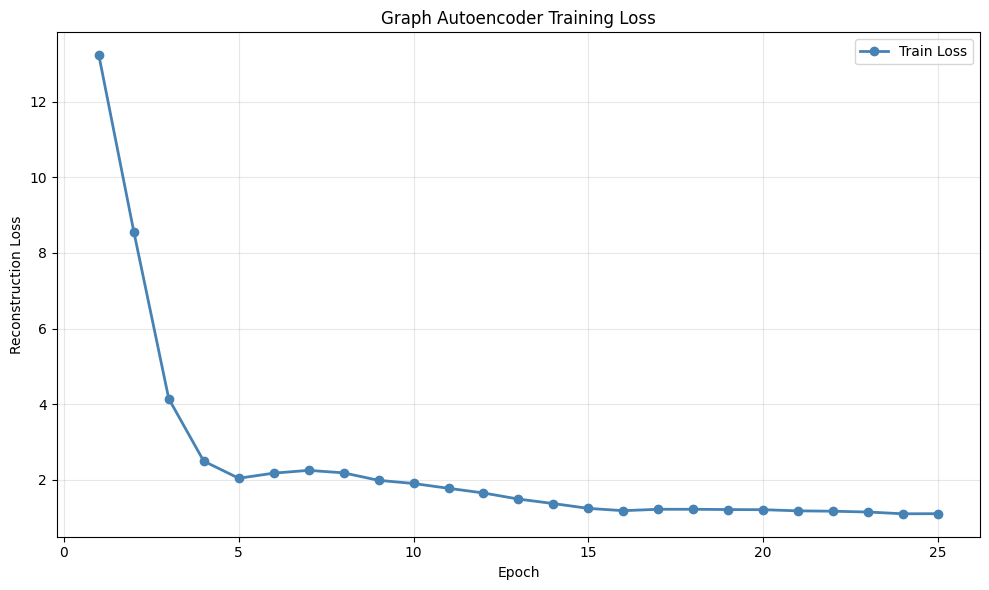

In [15]:
# ── GAE Training Loss Curve ──────────────────────────────────────────────────
# EXPLANATION: This plot shows how the reconstruction loss decreased over
# training epochs. A steadily falling curve means the GAE is learning to
# reconstruct the gene regulatory graph from the latent embeddings.
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(gae_losses) + 1), gae_losses,
         marker='o', linewidth=2, color='steelblue', label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss')
plt.title('Graph Autoencoder Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Once trained, generate the final embeddings (detached from the gradient graph)

In [16]:

gae_model.eval()
with torch.no_grad():
    Z_train = gae_model.encode(X_train_tensor, edge_index).cpu().numpy()

In [17]:
from sklearn.model_selection import train_test_split

# 1. Get the row indices for the Target Genes
target_indices = [gene_to_index[g] for g in Y_train_df.index
                  if g in gene_to_index]

# 2. RF Inputs: The 32-D embeddings of the TARGET Genes
# Assuming Z_train is already a NumPy array from your GAE extraction step
rf_inputs = Z_train[target_indices]

# 3. RF Targets: The actual expression values of the TARGET Genes
# Convert Y_train_tensor to a NumPy array
rf_targets = Y_train_tensor.cpu().numpy() if hasattr(Y_train_tensor, 'cpu') else Y_train_tensor

print(f"Random Forest Input Shape: {rf_inputs.shape}")
print(f"Random Forest Target Shape: {rf_targets.shape}")

# 4. Split our Target Genes (rows) into 80% Train and 20% Test
X_train_genes, X_test_genes, Y_train_genes, Y_test_genes = train_test_split(
    rf_inputs,
    rf_targets,
    test_size=0.20,
    random_state=42
)



Random Forest Input Shape: (17893, 32)
Random Forest Target Shape: (17893, 558)


In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X_train_rf = X_train_genes
Y_train_rf = Y_train_genes
X_test_rf = X_test_genes
Y_test_rf = Y_test_genes

# 2. Initialize the Random Forest Regressor
# n_estimators is the number of trees. n_jobs=-1 uses all available CPU cores.
print("Training Random Forest Regressor (this might take a moment)...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 3. Train the model on the 80% split
rf_model.fit(X_train_rf, Y_train_rf)

# 4. Predict on the 20% unseen test set
Y_pred_rf = rf_model.predict(X_test_rf)

# 5. Evaluate Performance
mse = mean_squared_error(Y_test_rf, Y_pred_rf)
rmse = np.sqrt(mse)

# Calculate R2 score (Variance explained)
r2 = r2_score(Y_test_rf, Y_pred_rf)

print("\n--- Random Forest Performance ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Overall R-squared (R2) Score: {r2:.4f}")

Training Random Forest Regressor (this might take a moment)...

--- Random Forest Performance ---
Mean Squared Error (MSE): 0.2184
Root Mean Squared Error (RMSE): 0.4674
Overall R-squared (R2) Score: 0.7787


In [19]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import spearmanr

def get_random_forest_results(rf_model, Y_train, Y_test, X_train, X_test,
                              scaler=None, train_exps=None, all_exps=None):
    """
    Evaluates a trained Random Forest model and returns a DataFrame of metrics.
    Safely handles inverse_transform when the model predicts a subset of the originally scaled columns.
    """
    # 1. Get Predictions
    train_pred = rf_model.predict(X_train)
    test_pred = rf_model.predict(X_test)

    # 2. Convert PyTorch tensors to NumPy if necessary
    train_tar = Y_train.cpu().numpy() if hasattr(Y_train, 'cpu') else Y_train
    test_tar = Y_test.cpu().numpy() if hasattr(Y_test, 'cpu') else Y_test

    # 3. Calculate Scaled Metrics
    mse_scaled_train = mean_squared_error(train_tar, train_pred)
    mse_scaled_test = mean_squared_error(test_tar, test_pred)

    spearman_train, _ = spearmanr(train_tar.flatten(), train_pred.flatten())
    spearman_test, _ = spearmanr(test_tar.flatten(), test_pred.flatten())

    # 4. Calculate TPM (Unscaled) Metrics Safely
    if scaler is not None and train_exps is not None and all_exps is not None:
        # Find the specific indices of the 558 columns within the original 698
        col_indices = [all_exps.index(col) for col in train_exps]

        # Extract just the mean and scale for the 558 predicted columns
        sub_mean = scaler.mean_[col_indices]
        sub_scale = scaler.scale_[col_indices]

        # Manually inverse transform: X_original = (X_scaled * scale) + mean
        train_tar_tpm = (train_tar * sub_scale) + sub_mean
        train_pred_tpm = (train_pred * sub_scale) + sub_mean
        test_tar_tpm = (test_tar * sub_scale) + sub_mean
        test_pred_tpm = (test_pred * sub_scale) + sub_mean

        mae_tpm_train = mean_absolute_error(train_tar_tpm, train_pred_tpm)
        mae_tpm_test = mean_absolute_error(test_tar_tpm, test_pred_tpm)
        mse_tpm_train = mean_squared_error(train_tar_tpm, train_pred_tpm)
        mse_tpm_test = mean_squared_error(test_tar_tpm, test_pred_tpm)

    elif scaler is not None and train_tar.shape[1] == len(scaler.mean_):
        # Fallback if shapes match perfectly
        train_tar_tpm = scaler.inverse_transform(train_tar)
        train_pred_tpm = scaler.inverse_transform(train_pred)
        test_tar_tpm = scaler.inverse_transform(test_tar)
        test_pred_tpm = scaler.inverse_transform(test_pred)

        mae_tpm_train = mean_absolute_error(train_tar_tpm, train_pred_tpm)
        mae_tpm_test = mean_absolute_error(test_tar_tpm, test_pred_tpm)
        mse_tpm_train = mean_squared_error(train_tar_tpm, train_pred_tpm)
        mse_tpm_test = mean_squared_error(test_tar_tpm, test_pred_tpm)
    else:
        # If we can't safely unscale, default to None or 0
        mae_tpm_train, mae_tpm_test = 0, 0
        mse_tpm_train, mse_tpm_test = 0, 0

    # 5. Build Results DataFrame
    results_dict = {
        "Metric": ["MSE (Scaled)", "MAE (TPM)", "MSE (TPM)", "Spearman Correlation"],
        "Train (Seen Genes)": [mse_scaled_train, mae_tpm_train, mse_tpm_train, spearman_train],
        "Test (Unseen Genes)": [mse_scaled_test, mae_tpm_test, mse_tpm_test, spearman_test]
    }

    return pd.DataFrame(results_dict), (train_tar, train_pred, test_tar, test_pred)

In [20]:
rf_results_df, (rf_train_tar, rf_train_pred, rf_test_tar, rf_test_pred) = get_random_forest_results(
    rf_model=rf_model,
    Y_train=Y_train_rf,
    Y_test=Y_test_rf,
    X_train=X_train_rf,
    X_test=X_test_rf,
    scaler=scaler,
    train_exps=train_exps,
    all_exps=clean_exp_data.columns.tolist() )

display(rf_results_df.round(4))

,Metric,Train (Seen Genes),Test (Unseen Genes)
0,MSE (Scaled),0.0307,0.2184
1,MAE (TPM),0.1708,0.4598
2,MSE (TPM),0.0768,0.5471
3,Spearman Correlation,0.9680,0.8883


## Evaluation Plots

The cells below add comprehensive visualizations for evaluating the Random Forest model performance.

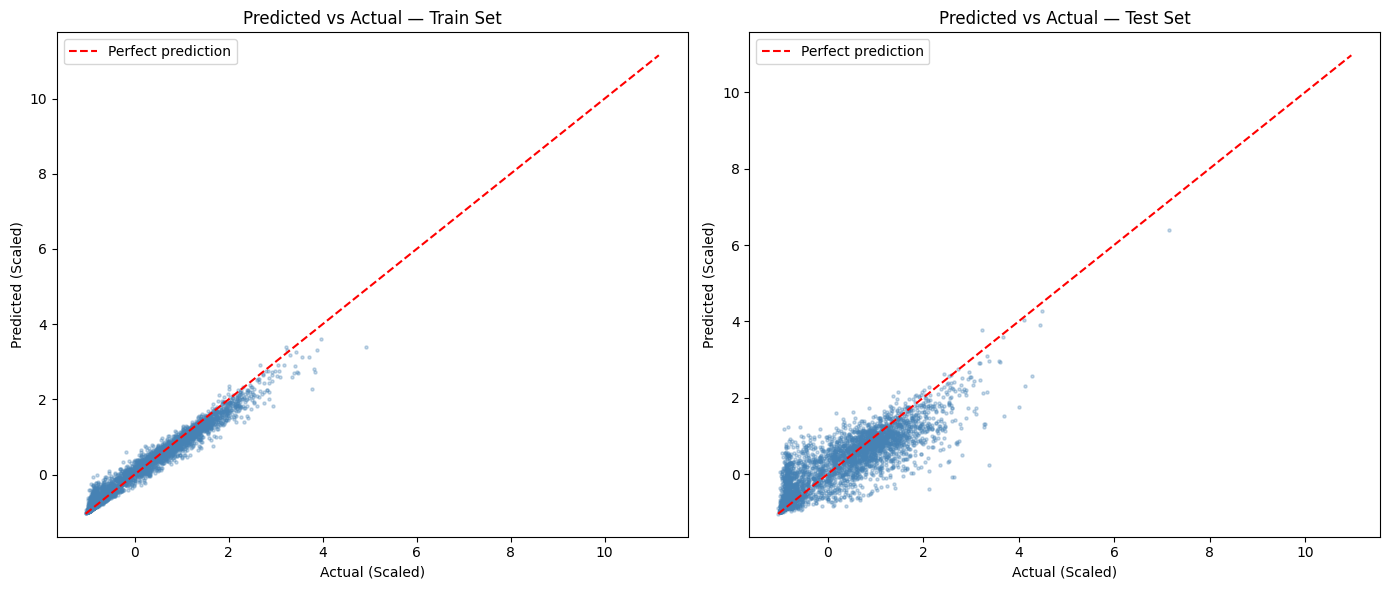

In [21]:
# ── PLOT 1: Predicted vs Actual (Scatter) ────────────────────────────────────
# EXPLANATION: Compares predicted expression values against true values on a
# sample of test data. Points along the diagonal y=x line indicate perfect
# prediction. Deviations reveal systematic over- or under-prediction.

# Sample a subset to keep the plot readable (~5,000 points)
n_sample = min(5000, rf_test_tar.size)
flat_true = rf_test_tar.flatten()
flat_pred = rf_test_pred.flatten()
rng = np.random.default_rng(42)
idx = rng.choice(len(flat_true), n_sample, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, split, true, pred in [
    (axes[0], 'Train', rf_train_tar.flatten(), rf_train_pred.flatten()),
    (axes[1], 'Test',  flat_true, flat_pred)
]:
    s_idx = rng.choice(len(true), min(5000, len(true)), replace=False)
    ax.scatter(true[s_idx], pred[s_idx], alpha=0.3, s=5, color='steelblue')
    lim = [min(true.min(), pred.min()), max(true.max(), pred.max())]
    ax.plot(lim, lim, 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual (Scaled)')
    ax.set_ylabel('Predicted (Scaled)')
    ax.set_title(f'Predicted vs Actual — {split} Set')
    ax.legend()

plt.tight_layout()
plt.show()

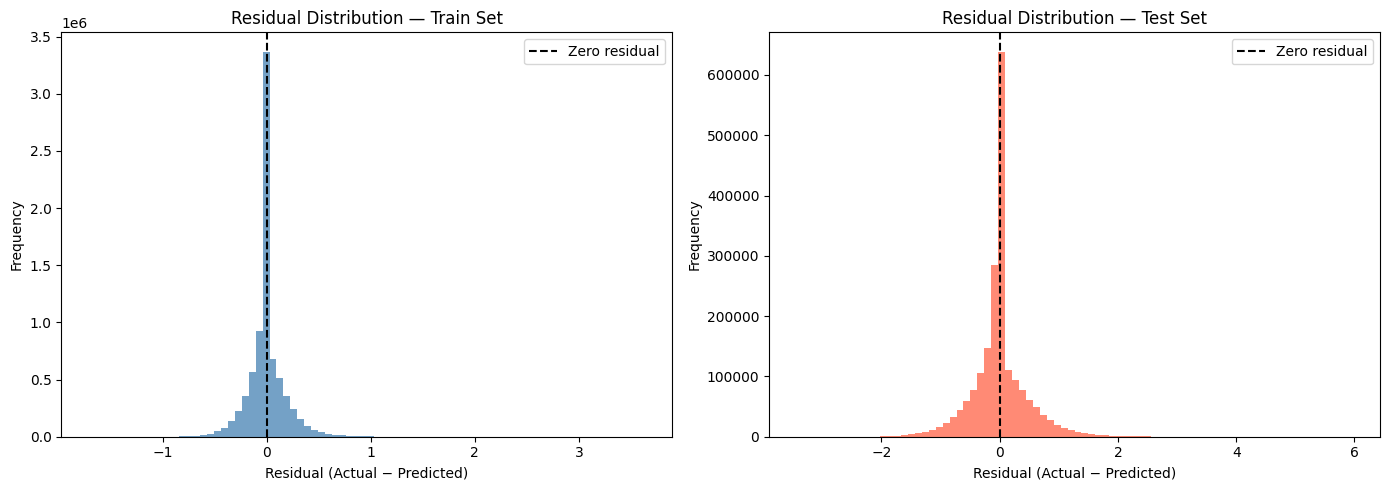

In [22]:
# ── PLOT 2: Residuals Distribution ───────────────────────────────────────────
# EXPLANATION: Residuals = Actual − Predicted. A distribution centered at 0
# indicates unbiased predictions. Wide or skewed distributions indicate
# systematic error or high variance in predictions.

train_residuals = rf_train_tar.flatten() - rf_train_pred.flatten()
test_residuals  = rf_test_tar.flatten()  - rf_test_pred.flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, residuals, split, color in [
    (axes[0], train_residuals, 'Train', 'steelblue'),
    (axes[1], test_residuals,  'Test',  'tomato')
]:
    ax.hist(residuals, bins=80, color=color, alpha=0.75, edgecolor='none')
    ax.axvline(0, color='black', linewidth=1.5, linestyle='--', label='Zero residual')
    ax.set_xlabel('Residual (Actual − Predicted)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Residual Distribution — {split} Set')
    ax.legend()

plt.tight_layout()
plt.show()

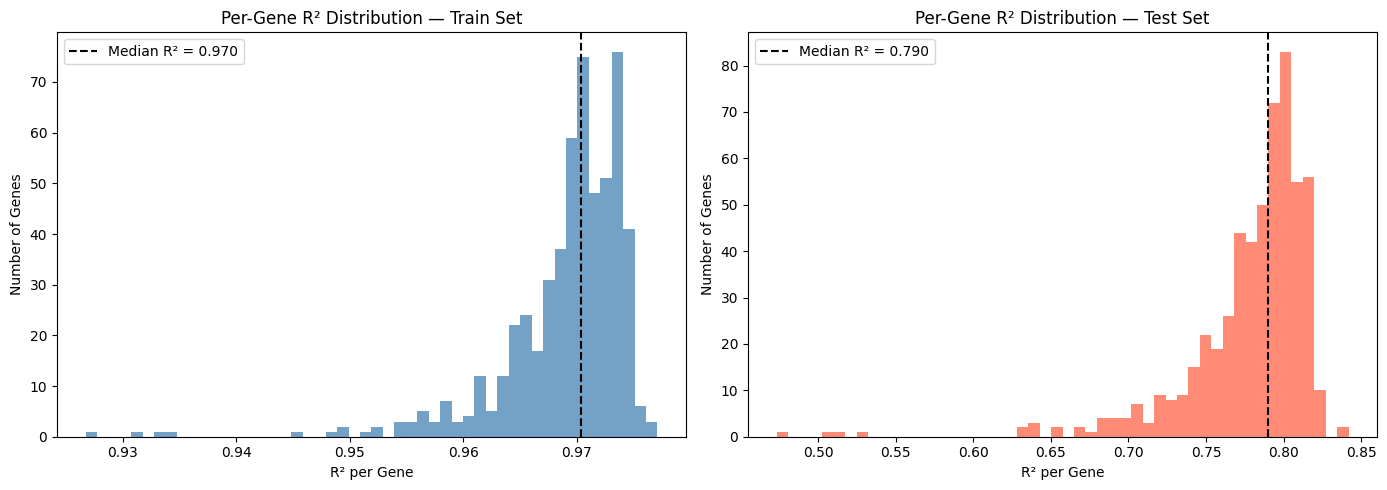

In [23]:
# ── PLOT 3: Per-Gene R² Distribution ─────────────────────────────────────────
# EXPLANATION: Computes R² (variance explained) for each individual target
# gene. This reveals how uniformly well the model performs across all genes —
# some genes may be predicted much better than others.

from sklearn.metrics import r2_score

def per_gene_r2(true, pred):
    """Returns R² for each gene (column) separately."""
    r2_vals = []
    for col in range(true.shape[1]):
        ss_res = np.sum((true[:, col] - pred[:, col]) ** 2)
        ss_tot = np.sum((true[:, col] - true[:, col].mean()) ** 2)
        r2_vals.append(1 - ss_res / ss_tot if ss_tot > 0 else np.nan)
    return np.array(r2_vals)

train_r2_per_gene = per_gene_r2(rf_train_tar, rf_train_pred)
test_r2_per_gene  = per_gene_r2(rf_test_tar,  rf_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, r2_vals, split, color in [
    (axes[0], train_r2_per_gene, 'Train', 'steelblue'),
    (axes[1], test_r2_per_gene,  'Test',  'tomato')
]:
    ax.hist(r2_vals[~np.isnan(r2_vals)], bins=50, color=color, alpha=0.75, edgecolor='none')
    median_r2 = np.nanmedian(r2_vals)
    ax.axvline(median_r2, color='black', linestyle='--',
               linewidth=1.5, label=f'Median R² = {median_r2:.3f}')
    ax.set_xlabel('R² per Gene')
    ax.set_ylabel('Number of Genes')
    ax.set_title(f'Per-Gene R² Distribution — {split} Set')
    ax.legend()

plt.tight_layout()
plt.show()

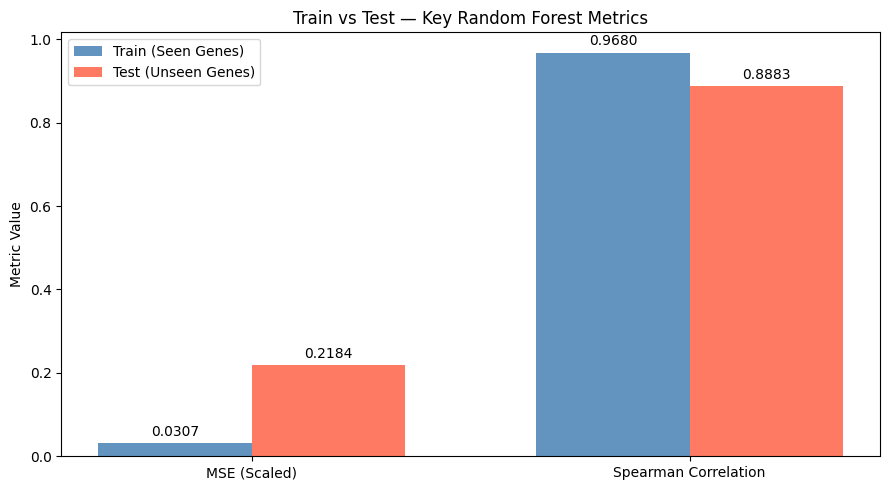

In [24]:
# ── PLOT 4: Train vs Test Metric Comparison (Bar Chart) ──────────────────────
# EXPLANATION: Side-by-side bar chart of key metrics for train vs test splits.
# Large gaps between train and test bars are a sign of overfitting.

metrics_to_plot = rf_results_df[rf_results_df['Metric'].isin(['MSE (Scaled)', 'Spearman Correlation'])].copy()

x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars_train = ax.bar(x - width/2, metrics_to_plot['Train (Seen Genes)'],
                    width, label='Train (Seen Genes)', color='steelblue', alpha=0.85)
bars_test  = ax.bar(x + width/2, metrics_to_plot['Test (Unseen Genes)'],
                    width, label='Test (Unseen Genes)', color='tomato', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot['Metric'])
ax.set_ylabel('Metric Value')
ax.set_title('Train vs Test — Key Random Forest Metrics')
ax.legend()
ax.bar_label(bars_train, fmt='%.4f', padding=3)
ax.bar_label(bars_test,  fmt='%.4f', padding=3)

plt.tight_layout()
plt.show()

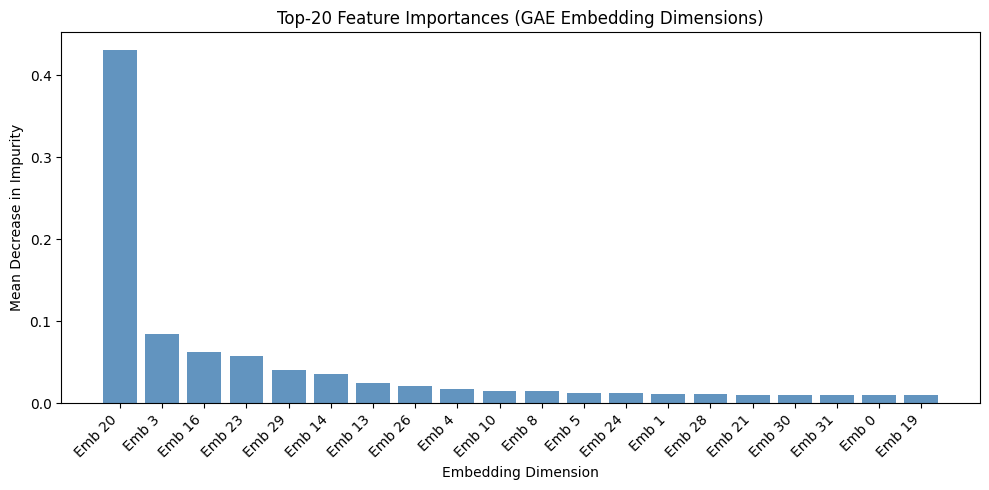

In [25]:
# ── PLOT 5: Feature Importances (Top 20) ─────────────────────────────────────
# EXPLANATION: Shows which of the 32 GAE embedding dimensions the Random
# Forest relies on most. High-importance features drive most predictions;
# very low-importance features may be candidates for dimensionality reduction.

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:20]  # top 20

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(20), importances[indices], color='steelblue', alpha=0.85)
ax.set_xticks(range(20))
ax.set_xticklabels([f'Emb {i}' for i in indices], rotation=45, ha='right')
ax.set_xlabel('Embedding Dimension')
ax.set_ylabel('Mean Decrease in Impurity')
ax.set_title('Top-20 Feature Importances (GAE Embedding Dimensions)')
plt.tight_layout()
plt.show()

,Metric,Train (Seen Genes),Test (Unseen Genes)
0,MSE (Scaled),0.0307,0.2184
1,MAE (TPM),0.1708,0.4598
2,MSE (TPM),0.0768,0.5471
3,Spearman Correlation,0.9680,0.8883


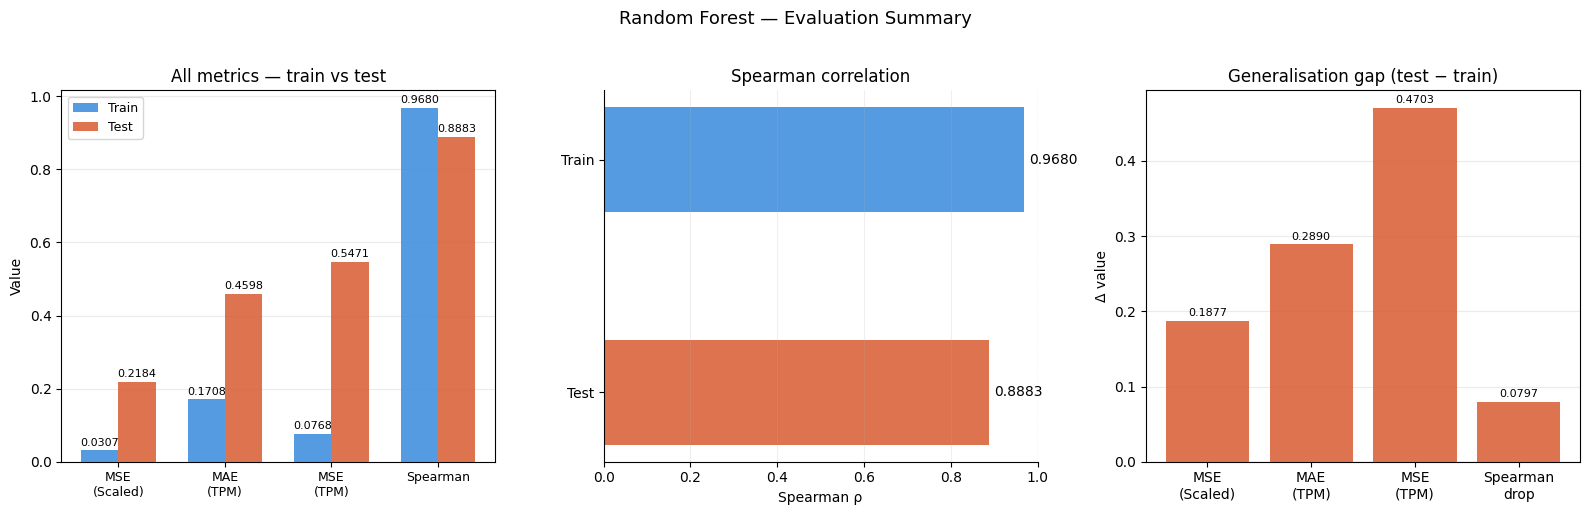

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import spearmanr

# ── 1. Predictions ────────────────────────────────────────────────
train_pred = rf_model.predict(X_train_rf)
test_pred  = rf_model.predict(X_test_rf)

train_tar  = Y_train_rf if isinstance(Y_train_rf, np.ndarray) \
             else Y_train_rf.cpu().numpy()
test_tar   = Y_test_rf  if isinstance(Y_test_rf,  np.ndarray) \
             else Y_test_rf.cpu().numpy()

# ── 2. MSE (Scaled) ───────────────────────────────────────────────
mse_train = mean_squared_error(train_tar, train_pred)
mse_test  = mean_squared_error(test_tar,  test_pred)

# ── 3. Inverse-transform → TPM space ─────────────────────────────
all_exps   = clean_exp_data.columns.tolist()
col_idx    = [all_exps.index(c) for c in train_exps]
sub_mean   = scaler.mean_[col_idx]
sub_scale  = scaler.scale_[col_idx]

train_tar_tpm  = train_tar  * sub_scale + sub_mean
train_pred_tpm = train_pred * sub_scale + sub_mean
test_tar_tpm   = test_tar   * sub_scale + sub_mean
test_pred_tpm  = test_pred  * sub_scale + sub_mean

# ── 4. MAE (TPM) & MSE (TPM) ──────────────────────────────────────
mae_tpm_train = mean_absolute_error(train_tar_tpm, train_pred_tpm)
mae_tpm_test  = mean_absolute_error(test_tar_tpm,  test_pred_tpm)
mse_tpm_train = mean_squared_error(train_tar_tpm, train_pred_tpm)
mse_tpm_test  = mean_squared_error(test_tar_tpm,  test_pred_tpm)

# ── 5. Spearman Correlation ───────────────────────────────────────
sp_train, _ = spearmanr(train_tar.flatten(), train_pred.flatten())
sp_test,  _ = spearmanr(test_tar.flatten(),  test_pred.flatten())

# ── 6. Results table ──────────────────────────────────────────────
results_df = pd.DataFrame({
    "Metric"             : ["MSE (Scaled)", "MAE (TPM)", "MSE (TPM)", "Spearman Correlation"],
    "Train (Seen Genes)" : [mse_train, mae_tpm_train, mse_tpm_train, sp_train],
    "Test (Unseen Genes)": [mse_test,  mae_tpm_test,  mse_tpm_test,  sp_test],
})
display(results_df.round(4))

# ── 7. Plots ──────────────────────────────────────────────────────
BLUE, CORAL = "#378ADD", "#D85A30"

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Random Forest — Evaluation Summary", fontsize=13, fontweight="500", y=1.02)

# Plot A: grouped bar — all four metrics
metrics = ["MSE\n(Scaled)", "MAE\n(TPM)", "MSE\n(TPM)", "Spearman"]
x = np.arange(len(metrics))
w = 0.35
ax = axes[0]
b1 = ax.bar(x - w/2, [mse_train, mae_tpm_train, mse_tpm_train, sp_train],
          w, label="Train", color=BLUE,  alpha=0.85, zorder=3)
b2 = ax.bar(x + w/2, [mse_test,  mae_tpm_test,  mse_tpm_test,  sp_test],
          w, label="Test",  color=CORAL, alpha=0.85, zorder=3)
ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=9)
ax.bar_label(b1, fmt="%.4f", fontsize=8, padding=2)
ax.bar_label(b2, fmt="%.4f", fontsize=8, padding=2)
ax.set_title("All metrics — train vs test"); ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.25, zorder=0)
ax.set_ylabel("Value")

# Plot B: Spearman gauge (horizontal bar)
ax = axes[1]
ax.barh(["Test", "Train"], [sp_test, sp_train],
       color=[CORAL, BLUE], alpha=0.85, height=0.45)
ax.set_xlim(0, 1)
ax.axvline(1, color="#aaa", lw=0.8, ls="--")
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
ax.set_xlabel("Spearman ρ")
ax.set_title("Spearman correlation")
ax.bar_label(ax.containers[0], fmt="%.4f", padding=4, fontsize=10)
ax.grid(axis="x", alpha=0.2)

# Plot C: generalisation gap (test − train for errors, train − test for Spearman)
ax = axes[2]
gap_labels = ["MSE\n(Scaled)", "MAE\n(TPM)", "MSE\n(TPM)", "Spearman\ndrop"]
gaps = [
    mse_test  - mse_train,
    mae_tpm_test  - mae_tpm_train,
    mse_tpm_test  - mse_tpm_train,
    sp_train  - sp_test,
]
colors = [CORAL if g > 0 else BLUE for g in gaps]
bars = ax.bar(gap_labels, gaps, color=colors, alpha=0.85, zorder=3)
ax.axhline(0, color="#aaa", lw=0.8)
ax.bar_label(bars, fmt="%.4f", fontsize=8, padding=2)
ax.set_title("Generalisation gap (test − train)")
ax.set_ylabel("Δ value")
ax.grid(axis="y", alpha=0.25, zorder=0)

plt.tight_layout()
plt.show()

In [27]:
import networkx as nx
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# ── Build NetworkX graph from the edge_index tensor ───────────────
ei = edge_index.cpu().numpy()  # shape (2, E)
G  = nx.DiGraph()
G.add_edges_from(zip(ei[0], ei[1]))

# ── 1. Degree centrality (log10) ──────────────────────────────────
deg_cent   = nx.degree_centrality(G)

# ── 2. Kleinberg Authority score ──────────────────────────────────
_, authority = nx.hits(G, max_iter=500, tol=1e-6)

# ── 3. Harmonic centrality ────────────────────────────────────────
harmonic   = nx.harmonic_centrality(G.to_undirected())

# ── Assemble per-gene stats DataFrame ────────────────────────────
net_stats_df = pd.DataFrame({
    "gene_idx"        : target_indices,
    "log10_degree"    : [np.log10(deg_cent.get(i, 1e-10) + 1e-10)
                          for i in target_indices],
    "authority"       : [authority.get(i, 0.0)
                          for i in target_indices],
    "harmonic"        : [harmonic.get(i, 0.0)
                          for i in target_indices],
})

print(net_stats_df.head())
print(f"Network stats computed for {len(net_stats_df)} target genes.")

   gene_idx  log10_degree  authority  harmonic
0         0      -9.69897        0.0       0.0
1         1      -9.69897        0.0       0.0
2         2      -9.69897        0.0       0.0
3         3      -9.69897        0.0       0.0
4         4      -9.69897        0.0       0.0
Network stats computed for 17893 target genes.


In [31]:
from sklearn.model_selection import train_test_split

row_idx = np.arange(len(rf_inputs))

_, _, _, _, train_row_idx, test_row_idx = train_test_split(
    rf_inputs, rf_targets, row_idx,
    test_size=0.20, random_state=42
)

print(f"test_row_idx length : {len(test_row_idx)}")
print(f"rf_test_tar rows    : {rf_test_tar.shape[0]}")

per_gene_spearman = np.array([
    spearmanr(rf_test_tar[g], rf_test_pred[g])[0]
    if not np.isnan(spearmanr(rf_test_tar[g], rf_test_pred[g])[0]) else 0.0
    for g in range(rf_test_tar.shape[0])
])

net_test = net_stats_df.iloc[test_row_idx].reset_index(drop=True)

print(f"net_test rows       : {len(net_test)}")
assert len(net_test) == len(per_gene_spearman), "Size mismatch — check random_state"

all_exps  = clean_exp_data.columns.tolist()
col_idx   = [all_exps.index(c) for c in train_exps]
sub_mean  = scaler.mean_[col_idx]
sub_scale = scaler.scale_[col_idx]
test_tpm  = rf_test_tar * sub_scale + sub_mean

expr_stats_df = pd.DataFrame({
    "per_gene_spearman": per_gene_spearman,
    "expr_mean"        : test_tpm.mean(axis=1),
    "expr_median"      : np.median(test_tpm, axis=1),
    "expr_variance"    : test_tpm.var(axis=1),
})
print(expr_stats_df.describe().round(4))

test_row_idx length : 3579
rf_test_tar rows    : 3579
net_test rows       : 3579
       per_gene_spearman  expr_mean  expr_median  expr_variance
count          3579.0000  3579.0000    3579.0000      3579.0000
mean              0.6938     1.3326       1.2553         0.6682
std               0.2630     1.3678       1.4449         0.9669
min              -0.6091    -0.0000      -0.0000         0.0000
25%               0.5520     0.0331       0.0000         0.0313
50%               0.7478     0.8881       0.4247         0.4356
75%               0.9030     2.4728       2.5111         0.8743
max               1.0000     5.8882       6.1424        11.3108


In [32]:
rho_deg,  _ = spearmanr(per_gene_spearman, net_test["log10_degree"])
rho_auth, _ = spearmanr(per_gene_spearman, net_test["authority"])
rho_harm, _ = spearmanr(per_gene_spearman, net_test["harmonic"])
rho_mean, _ = spearmanr(per_gene_spearman, expr_stats_df["expr_mean"])
rho_med,  _ = spearmanr(per_gene_spearman, expr_stats_df["expr_median"])
rho_var,  _ = spearmanr(per_gene_spearman, expr_stats_df["expr_variance"])

summary = pd.DataFrame({
    "Statistic"    : ["Log10 Degree Centrality", "Kleinberg Authority",
                       "Harmonic Centrality", "Expression Mean",
                       "Expression Median", "Expression Variance"],
    "Category"     : ["Network"]*3 + ["Expression"]*3,
    "Spearman rho" : [rho_deg, rho_auth, rho_harm,
                       rho_mean, rho_med, rho_var],
    "Paper value"  : [0.051, 0.055, 0.022, -0.028, -0.027, -0.0058],
})
display(summary.round(4))

,Statistic,Category,Spearman rho,Paper value
0,Log10 Degree Centrality,Network,-0.2882,0.0510
1,Kleinberg Authority,Network,-0.2782,0.0550
2,Harmonic Centrality,Network,-0.2840,0.0220
3,Expression Mean,Expression,-0.4846,-0.0280
4,Expression Median,Expression,-0.4732,-0.0270
5,Expression Variance,Expression,-0.4539,-0.0058


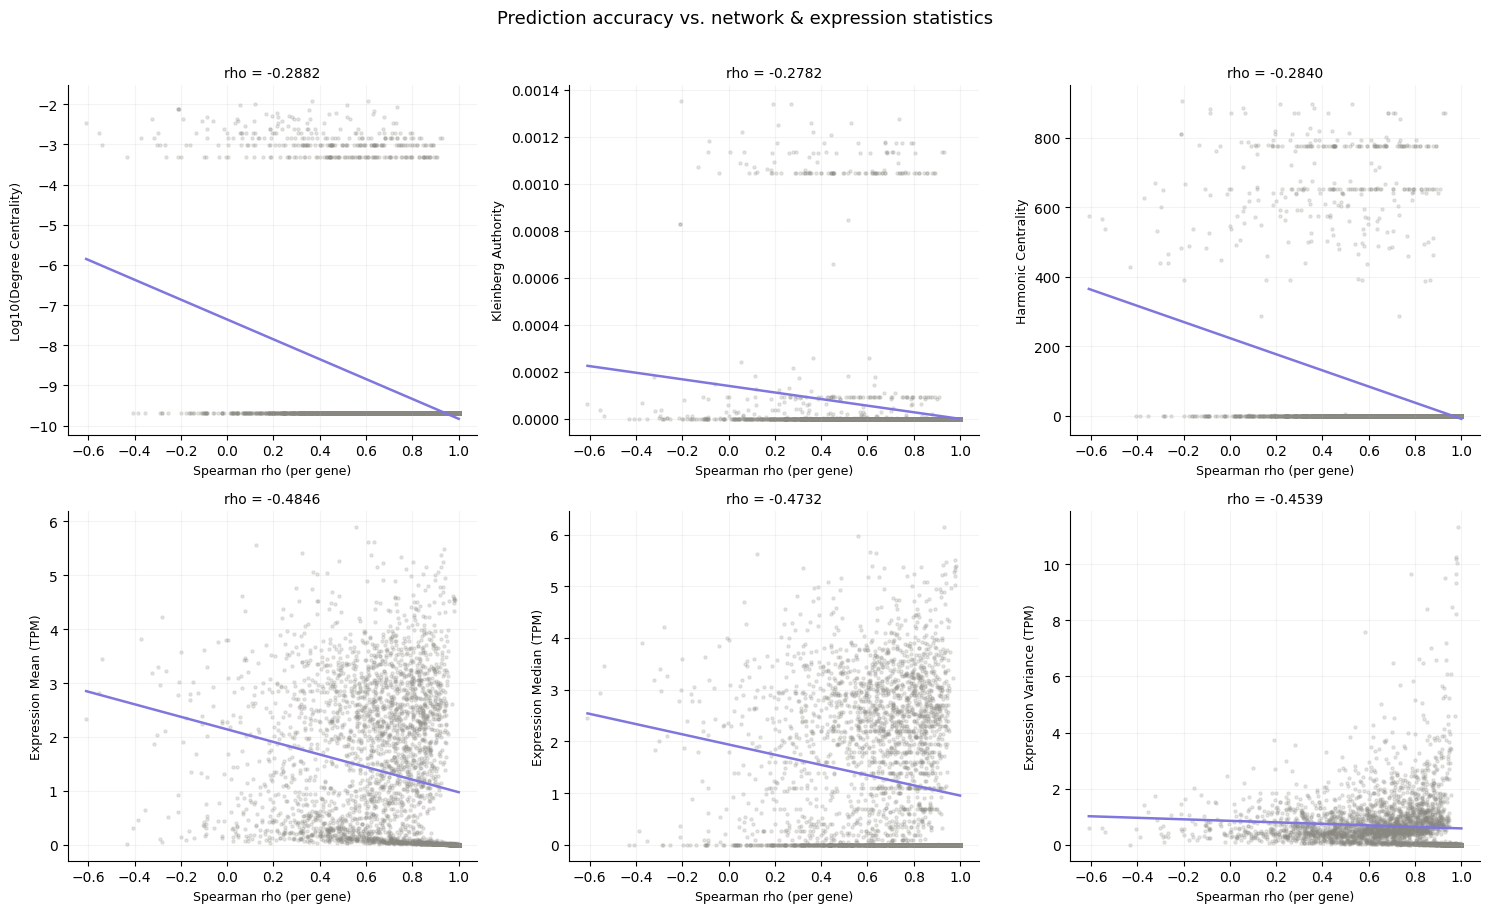

In [33]:
import matplotlib.pyplot as plt

GRAY = "#888780"
y    = per_gene_spearman

plot_cfg = [
    (net_test["log10_degree"],    "Log10(Degree Centrality)",   rho_deg),
    (net_test["authority"],       "Kleinberg Authority",         rho_auth),
    (net_test["harmonic"],        "Harmonic Centrality",         rho_harm),
    (expr_stats_df["expr_mean"],    "Expression Mean (TPM)",     rho_mean),
    (expr_stats_df["expr_median"],  "Expression Median (TPM)",   rho_med),
    (expr_stats_df["expr_variance"],"Expression Variance (TPM)", rho_var),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Prediction accuracy vs. network & expression statistics",
             fontsize=13, fontweight="500", y=1.01)

for ax, (x, xlabel, rho) in zip(axes.flat, plot_cfg):
    ax.scatter(y, x, alpha=0.2, s=5, color=GRAY, rasterized=True)
    m, b = np.polyfit(y, x, 1)
    xs   = np.linspace(y.min(), y.max(), 200)
    ax.plot(xs, m*xs + b, color="#7F77DD", lw=1.8)
    ax.set_xlabel("Spearman rho (per gene)", fontsize=9)
    ax.set_ylabel(xlabel, fontsize=9)
    ax.set_title(f"rho = {rho:.4f}", fontsize=10)
    ax.grid(alpha=0.15)
    for sp in ["top", "right"]: ax.spines[sp].set_visible(False)

plt.tight_layout()
plt.show()